# KITTY FILE

Here I test the functions for the KITTY dataset to make sure they work and don't produce any errors in further stages of the poject. Also, I make
some visualizations to better show the file contents and the results.

In [1]:
# GENERAL IMPORTS
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import time
import torch
import gc

# CUSTIM FUNCTIONS AND VARIABLES
from kitty import depth_read, listPicsWith, togglePath, MatchDepthToCar, KITTY_PATH
from yolo import getEmbedFromResults, getCropsFromResults, getEmbedFromCrops, CLASSES_YOLO, CONFIDENCE_YOLO
from utils import getDevice

# YOLO STUFF
from ultralytics import YOLO

#DINO STUFF
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

Using device: xpu :3
Using device: xpu :3
Using device: xpu :3
YOLO26n MODEL LOADED



/home/tim/sidehustle/thesis/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = getDevice()

Using device: xpu :3


Firstly, I wanted to take a look at the data presented. It is stored in 2 files: one with color image and one with depth info that is read using a special 
function provided in dev tools.

The code below shows the results. Error points, where value is negative and thus no depth is present are omitted.

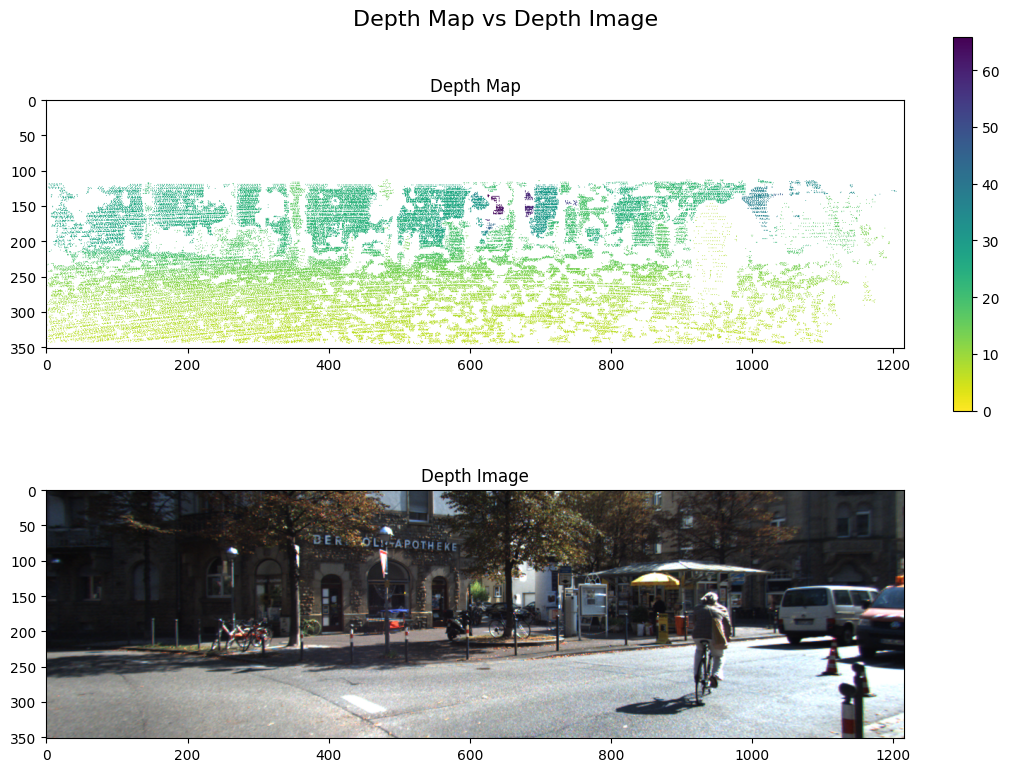

11876

In [3]:
depth_map = "../datasets/depth_selection/val_selection_cropped/groundtruth_depth/2011_09_26_drive_0005_sync_groundtruth_depth_0000000071_image_03.png"
depth_map_img = togglePath(depth_map)

depth_img = np.array(Image.open(depth_map_img), dtype=int)

depth_np = depth_read(depth_map)

cmap = plt.cm.viridis_r.copy()
cmap.set_under('white')   # values below vmin
cmap.set_over('white') 

fig, ax = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

# First image
im = ax[0].imshow(depth_np, cmap=cmap, vmin=0)
fig.colorbar(im, ax=ax[0])
ax[0].set_title("Depth Map")
ax[0].set_anchor('C')   # center image

# Second image
ax[1].imshow(depth_img)
ax[1].set_title("Depth Image")
ax[1].set_anchor('C')   # center image

plt.suptitle("Depth Map vs Depth Image", fontsize=16)
plt.show()

fig.savefig("../visualizations/depthmap_vs_image_kitty.png", dpi=300)

del depth_map, depth_map_img, depth_img, depth_np, cmap, fig, ax, im
gc.collect()

## Extracting true depth from an image

1. Find all images with cars in them with over 50% certainty
2. Use YOLO to find bounding boxes for each image
3. For each image:
    1. crop the depth image to the car bounding box
    2. convert depth using devkit function to m from image
    4. drop the invalid points (where depth is -1)
    3. compute exact value either as average or RANSACK fitted value in the middle of the image

Both avergaes and ransac predictions in the middle are stored in a numpy array for further visualizations

In [4]:
images_with_cars = listPicsWith(KITTY_PATH, CLASSES_YOLO, CONFIDENCE_YOLO, True)
gc.collect()

1000
2011_09_26_drive_0002_sync_image_0000000005_image_02.png
../datasets/depth_selection/val_selection_cropped/image/2011_09_26_drive_0002_sync_image_0000000005_image_02.png

0: 192x640 (no detections), 4.9ms
1: 192x640 (no detections), 4.9ms
2: 192x640 (no detections), 4.9ms
3: 192x640 (no detections), 4.9ms
4: 192x640 (no detections), 4.9ms
5: 192x640 (no detections), 4.9ms
6: 192x640 (no detections), 4.9ms
7: 192x640 (no detections), 4.9ms
8: 192x640 (no detections), 4.9ms
9: 192x640 (no detections), 4.9ms
10: 192x640 (no detections), 4.9ms
11: 192x640 (no detections), 4.9ms
12: 192x640 (no detections), 4.9ms
13: 192x640 (no detections), 4.9ms
14: 192x640 (no detections), 4.9ms
15: 192x640 (no detections), 4.9ms
16: 192x640 (no detections), 4.9ms
17: 192x640 (no detections), 4.9ms
18: 192x640 (no detections), 4.9ms
19: 192x640 (no detections), 4.9ms
20: 192x640 (no detections), 4.9ms
21: 192x640 1 car, 4.9ms
22: 192x640 1 car, 4.9ms
23: 192x640 1 car, 4.9ms
24: 192x640 1 car, 4.9ms

0

Dino model is loaded for embedding retrieval in the later stages of the process.

In [5]:
DINO_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

image_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_ID)
dinov3 = AutoModel.from_pretrained(
    DINO_MODEL_ID,
    dtype=torch.float16,
    device_map="auto"
).to(device)

def get_embedding(image):
    """
    Get DINOv3 embeddings from an image or a list of images. 
    Args:
        image: string path or PIL image or list of ready to pricess opened imaged
    """
    #case 1 - image is a path
    if type(image) == str:
        image = load_image(image)
    
    #case 2 is pil image already or compatible with the class
    inputs = image_processor(images=image, return_tensors="pt").to(device)

    #retrieve embeddings
    dinov3.eval()
    with torch.inference_mode():
        outputs = dinov3(**inputs)

    return outputs.pooler_output  # final embeddings

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2190.35it/s]


This section uses YOLO to get the forward pass data and based on that for each object find its true depth as well as embeddings.

In [6]:
model = YOLO("../build/yolo26n.pt").to(device)

start = time.time()
results = model.predict(images_with_cars, conf=CONFIDENCE_YOLO, classes=CLASSES_YOLO)
end = time.time()
print(f"Total time taken for YOLO predict: {end - start:.2f} seconds")


0: 192x640 1 car, 4.1ms
1: 192x640 1 car, 4.1ms
2: 192x640 1 car, 4.1ms
3: 192x640 1 car, 4.1ms
4: 192x640 1 car, 4.1ms
5: 192x640 1 car, 4.1ms
6: 192x640 1 car, 4.1ms
7: 192x640 1 car, 4.1ms
8: 192x640 1 car, 4.1ms
9: 192x640 1 car, 4.1ms
10: 192x640 2 cars, 4.1ms
11: 192x640 1 car, 4.1ms
12: 192x640 1 car, 4.1ms
13: 192x640 2 cars, 4.1ms
14: 192x640 2 cars, 4.1ms
15: 192x640 2 cars, 4.1ms
16: 192x640 1 car, 4.1ms
17: 192x640 2 cars, 4.1ms
18: 192x640 1 car, 4.1ms
19: 192x640 1 car, 4.1ms
20: 192x640 1 car, 4.1ms
21: 192x640 2 cars, 4.1ms
22: 192x640 1 car, 4.1ms
23: 192x640 1 car, 4.1ms
24: 192x640 1 car, 4.1ms
25: 192x640 2 cars, 4.1ms
26: 192x640 1 car, 4.1ms
27: 192x640 1 car, 4.1ms
28: 192x640 2 cars, 4.1ms
29: 192x640 2 cars, 4.1ms
30: 192x640 3 cars, 4.1ms
31: 192x640 4 cars, 4.1ms
32: 192x640 3 cars, 4.1ms
33: 192x640 4 cars, 4.1ms
34: 192x640 3 cars, 4.1ms
35: 192x640 5 cars, 4.1ms
36: 192x640 4 cars, 4.1ms
37: 192x640 5 cars, 4.1ms
38: 192x640 5 cars, 4.1ms
39: 192x640 6 ca

## Depths are retrieved from the bounding boxes and depth maps

In [7]:
start = time.time()
#RESULTS VARIABLES ARE PREPARED
ransac_preds_combined = np.array([])
avgs_combined = np.array([])


#LOOP FOR EVERY IMAGE
print("\nCALCULATING DEPTH:")
for i, image_path in enumerate(images_with_cars):
    #progress is printed
    if i % 100 == 0:
        print(f"Progress: {i/len(images_with_cars)*100:.2f}%")
    #i fetch current result
    result = results[i]

    #DEPTH IS RETRIEVED
    ransac_preds, avgs = MatchDepthToCar(image_path, result)

    ransac_preds_combined = np.append(ransac_preds_combined, ransac_preds)
    avgs_combined = np.append(avgs_combined, avgs)

#initial data types
print(f"TYPES:\nRANSAC: {type(ransac_preds_combined)};\nAVGS: {type(avgs_combined)};")

#conversion to tensors
ransac_tensor = torch.from_numpy(ransac_preds_combined).float()
torch.save(ransac_tensor, "../data/ransac_depth.pt")
del ransac_tensor
gc.collect()

avgs_tensor = torch.from_numpy(avgs_combined).float()
torch.save(avgs_tensor, "../data/avgs_depth.pt")
del avgs_tensor
gc.collect()

end = time.time()
print(f"Total time taken to find depths: {end - start:.2f} seconds")



CALCULATING DEPTH:
Progress: 0.00%
Progress: 12.95%
EMPTY SLICE OF THE IMAGE, NO DEPTH :(
EMPTY SLICE OF THE IMAGE, NO DEPTH :(
Progress: 25.91%
EMPTY SLICE OF THE IMAGE, NO DEPTH :(
Progress: 38.86%
EMPTY SLICE OF THE IMAGE, NO DEPTH :(
Progress: 51.81%
Progress: 64.77%
Progress: 77.72%
Progress: 90.67%
TYPES:
RANSAC: <class 'numpy.ndarray'>;
AVGS: <class 'numpy.ndarray'>;
Total time taken to find depths: 56.64 seconds


In [8]:
ratios_combined = (ransac_preds_combined-avgs_combined)/avgs_combined *100
ratios_combined_inv = (avgs_combined-ransac_preds_combined)/ransac_preds_combined *100

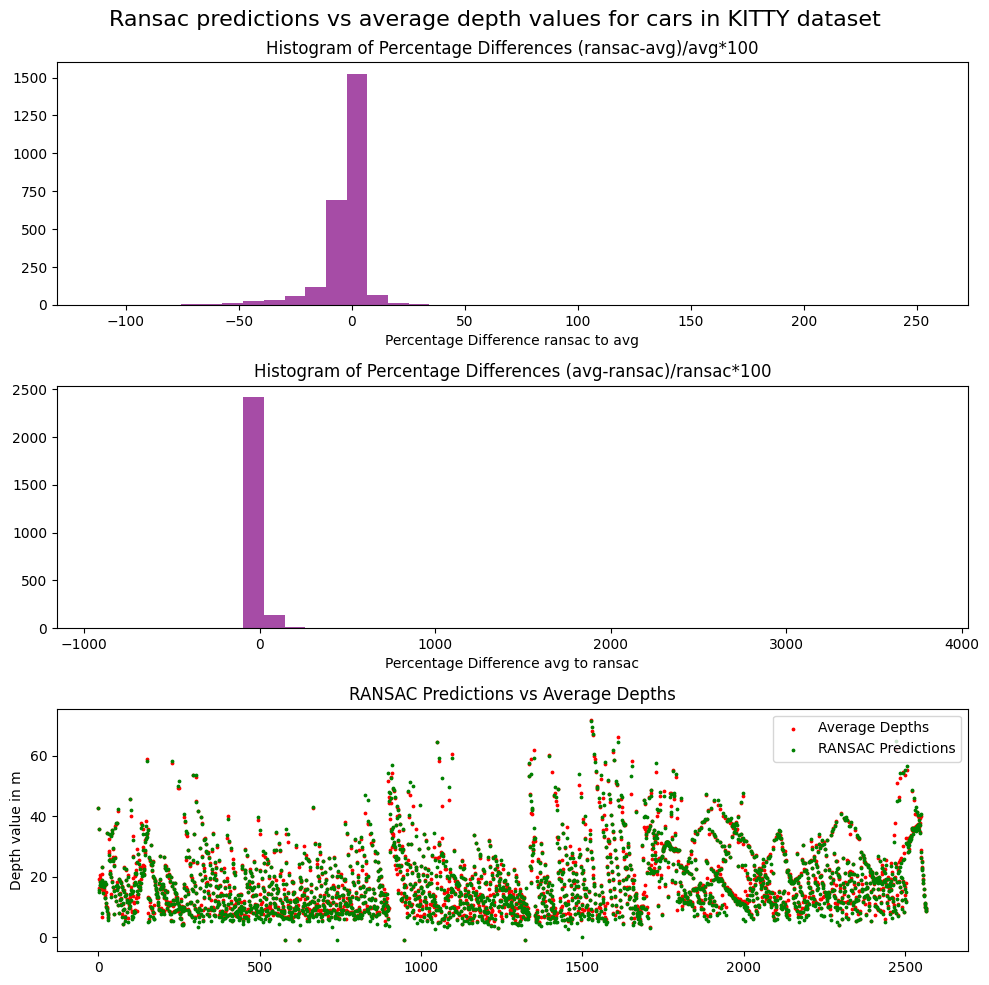

In [9]:
fig, ax = plt.subplots(nrows=3, ncols=1,figsize=(10, 10))

axes = ax.flatten()

axes[0].hist(ratios_combined, bins=40, color='purple', alpha=0.7)
axes[0].set_title('Histogram of Percentage Differences (ransac-avg)/avg*100')
axes[0].set_xlabel('Percentage Difference ransac to avg')

axes[1].hist(ratios_combined_inv, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Histogram of Percentage Differences (avg-ransac)/ransac*100')
axes[1].set_xlabel('Percentage Difference avg to ransac')

indicies = np.arange(len(ratios_combined))
axes[2].scatter(indicies, avgs_combined, color='red', label='Average Depths', s=3)
axes[2].scatter(indicies, ransac_preds_combined, color='green', label='RANSAC Predictions',s=3)
axes[2].set_title('RANSAC Predictions vs Average Depths')
axes[2].set_ylabel("Depth value in m")

plt.suptitle("Ransac predictions vs average depth values for cars in KITTY dataset", fontsize=16)
plt.tight_layout()
plt.legend()
plt.show()

fig.savefig("../visualizations/ransac_vs_avg.png", dpi=300)

In [10]:
del ratios_combined, ratios_combined_inv, indicies, fig, ax, axes, ransac_preds_combined, avgs_combined
gc.collect()

15357

In [11]:
# Source - https://stackoverflow.com/q/47447270
# Posted by user3226167, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-13, License - CC BY-SA 3.0

#abc.py
def lsos(all_obj = globals(),n=10):

    import sys

    object_name = list(all_obj)
    object_size = [ round(sys.getsizeof(all_obj[x])/1024.0/1024.0,4) for x in object_name]
    object_id = [id(all_obj[x]) for x in object_name]

    d = [(a,b,c) for a,b,c in zip(object_name, object_size, object_id)]
    d.sort(key = lambda x:(x[1],x[2]), reverse=True)
    dprint = d[0:min(len(d), n)]

    #print formating
    name_width_max = max([len(x[0]) for x in dprint])
    print(("{:<" + str(name_width_max +2) + "}{:11}{}").format("name","size_Mb","id"))
    fmt = '{{:<{}}}'.format(name_width_max+2) +"  "+ "{: 5.4f}" +"  "+ "{:d}"
    for line in dprint:
        print( fmt.format(*line))

    return

print("Top 20 objects in memory:")
lsos(n=20)
print("Top 20 objects in memory local:")
lsos(locals(), n=20)


Top 20 objects in memory:
name                size_Mb    id
images_with_cars       0.0066  140210932913856
results                0.0066  140209537459200
AutoModel              0.0016  94743405881552
AutoImageProcessor     0.0016  94743405848608
YOLO                   0.0016  94743270385504
_i7                    0.0011  94746717951824
_ii                    0.0010  94746721035248
_i9                    0.0010  94746721035248
_i11                   0.0010  94746718109376
_i3                    0.0009  94743116448960
_i5                    0.0008  94745292443504
_i1                    0.0006  94743116451888
_i6                    0.0003  140209332613552
open                   0.0002  140214545391584
_ih                    0.0002  140214379100288
In                     0.0002  140214379100288
_oh                    0.0002  140214379096320
Out                    0.0002  140214379096320
depth_read             0.0002  140213054744080
MatchDepthToCar        0.0002  140210911374048
Top 20 obj

In [ ]:
#EMBEDDINGS ARE RETRIEVED
embeds_yolo=[]
embeds_dino=[]

#embeds_yolo = getEmbedFromResults(results)
crops = getCropsFromResults(results)
print("\nEXTRACTING YOLO EMBEDDINGS:")
start = time.time()
embeds_yolo = getEmbedFromCrops(crops)
end = time.time()
print(f"Total time taken for YOLO embeddings extraction: {end - start:.2f} seconds")
print("\nEXTRACTING DINO EMBEDDINGS:")
start = time.time()
embeds_dino = get_embedding(crops)
end = time.time()
print(f"Total time taken for DINO embeddings extraction: {end - start:.2f} seconds")

del crops
gc.collect()

#WE NOW HOW THE TOTAL RESULTS FOR THE IMAGES
print(f"SHAPES:\nRANSAC {ransac_preds_combined.shape};\nAVGS: {avgs_combined.shape};\n")


EXTRACTING YOLO EMBEDDINGS:

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs



Saving the final results to a file as a torch tensor

In [ ]:
# embeds_tensor = torch.stack(embeds_list)
# torch.save(embeds_tensor, "../data/embeds_yolo.pt")
# del embeds_yolo, embeds_tensor
# gc.collect()
#torch.empty_cache()

In [ ]:
# Stream the generator chunk by chunk directly to disk
CHUNK_SIZE = 100  # tune this down if still OOM (try 50 or 10)
chunk = []
chunk_idx = 0
saved_files = []

torch.xpu.empty_cache()
gc.collect()


embeds_yolo = [embed.cpu() for embed in embeds_yolo]

for embed in embeds_yolo:
    chunk.append(embed)
    
    if len(chunk) == CHUNK_SIZE:
        chunk_tensor = torch.stack(chunk)
        path = f"../data/embeds_chunk_{chunk_idx}.pt"
        torch.save(chunk_tensor, path)
        saved_files.append(path)
        print(f"Saved chunk {chunk_idx}, shape: {chunk_tensor.shape}")
        
        del chunk_tensor, chunk
        chunk = []
        chunk_idx += 1
        gc.collect()

# Save any remaining embeddings
if chunk:
    chunk_tensor = torch.stack(chunk)
    path = f"../data/embeds_chunk_{chunk_idx}.pt"
    torch.save(chunk_tensor, path)
    saved_files.append(path)
    print(f"Saved final chunk {chunk_idx}, shape: {chunk_tensor.shape}")
    del chunk_tensor, chunk
    gc.collect()

print(f"\nSaved {len(saved_files)} chunk files")
print(f"Files: {saved_files}")

OutOfMemoryError: XPU out of memory. Tried to allocate 11.75 GiB. GPU 0 has a total capacity of 28.54 GiB. Of the allocated memory 3.39 GiB is allocated by PyTorch, and 1.48 GiB is reserved by PyTorch but unallocated. Please use `empty_cache` to release all unoccupied cached memory.

TYPES:
RANSAC: <class 'numpy.ndarray'>;
AVGS: <class 'numpy.ndarray'>;
EMBEDS: <class 'generator'>;



OutOfMemoryError: XPU out of memory. Tried to allocate 11.75 GiB. GPU 0 has a total capacity of 28.54 GiB. Of the allocated memory 3.37 GiB is allocated by PyTorch, and 1.76 GiB is reserved by PyTorch but unallocated. Please use `empty_cache` to release all unoccupied cached memory.

In [ ]:
# Verify saved files by reloading
ransac_check = torch.load("../data/ransac_depth.pt")
avgs_check   = torch.load("../data/avgs_depth.pt")
embeds_check = torch.load("../data/embeds_yolo.pt")

print(f"SHAPES:\nRANSAC: {ransac_check.shape}\nAVGS: {avgs_check.shape}\nEMBEDS: {embeds_check.shape}")

del ransac_check, avgs_check, embeds_check

In [ ]:
torch.save(embeds_dino, "../data/embeds_dino.pt")
del embeds_dino
gc.collect()

# Plotting results

After getting ransac values of the middle of the image I want to visualize the results.

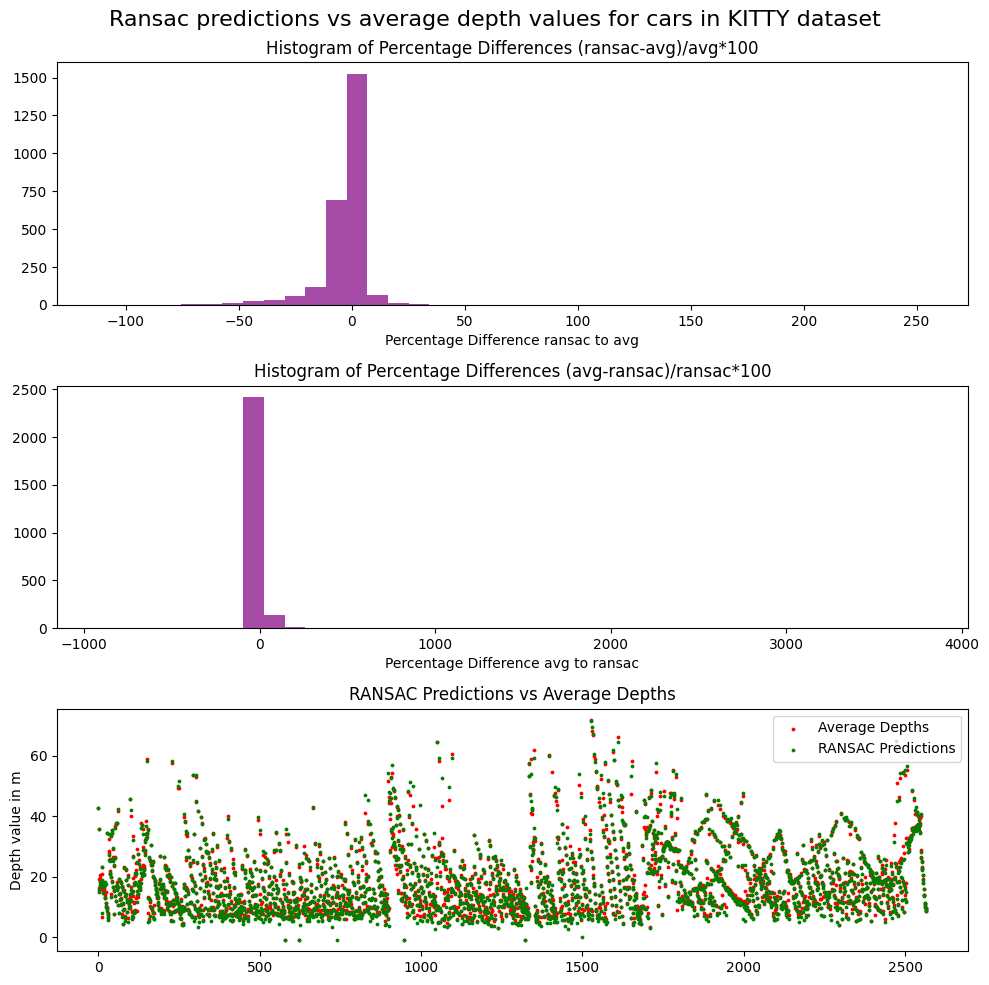